**A system that learns normal network behavior and detects anomalies (attacks)**

took raw network data and made it machine-readable

In [42]:
import pandas as pd
import time

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC



In [43]:
# =========================
# 1. Load IoT-23 Zeek file
# =========================

file_path = "/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"   # change this to your actual file name

# Get column names from #fields line
columns = None # Initialize columns to None
with open(file_path, "r") as f:
    for line in f:
        if line.startswith("#fields"):
            columns = line.strip().split("\t")[1:]
            break

# If columns were found, use them. Otherwise, pd.read_csv will infer names from the first row.
if columns:
    df = pd.read_csv(
        file_path,
        sep=",",
        comment="#",
        names=columns
    )
else:
    # If '#fields' line was not found, read the CSV without the 'names' argument.
    # Pandas will typically use the first non-comment line as the header.
    df = pd.read_csv(
        file_path,
        sep=",",
        comment="#"
    )
    print("Warning: '#fields' line not found in the file. Column names might be inferred from the data or might be incorrect.")

df.columns = df.columns.str.strip()

print("Original dataset shape:", df.shape)
print(df.head())

Original dataset shape: (225745, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                     

In [44]:
# =========================
# 2. Data cleaning
# =========================

# Clean column names
df.columns = df.columns.str.strip()

# Check labels BEFORE conversion
print("Before conversion:")
print(df["Label"].unique())
print(df["Label"].value_counts())

# Clean label text
df["Label"] = df["Label"].astype(str).str.strip().str.upper()

# Convert label:
# BENIGN = 0
# Anything else = 1
df["Label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

print("\nAfter conversion:")
print(df["Label"].value_counts())

# Replace infinity and missing values
df = df.replace([float("inf"), -float("inf")], 0)
df = df.fillna(0)

features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size"
]

df_model = df[features + ["Label"]].copy()

for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.fillna(0)

print("\nCleaned dataset shape:", df_model.shape)
print("\nLabel distribution:")
print(df_model["Label"].value_counts())

Before conversion:
['BENIGN' 'DDoS']
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

After conversion:
Label
1    128027
0     97718
Name: count, dtype: int64

Cleaned dataset shape: (225745, 11)

Label distribution:
Label
1    128027
0     97718
Name: count, dtype: int64


train Isolation Forest: “Here is a lot of network traffic data. Learn what normal behavior looks like

* The model tries to "separate" each data point.

* If it gets separated very quickly → it's weird → anomaly

* If it stays with others → it's normal

In [45]:
# =========================
# 3. Split X and y
# =========================

X = df_model[features]
y = df["Label"]

In [46]:
# =========================
# 4. Scale features
# =========================


# Scale again
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Recreate normal training data
X_train_normal = X_scaled[y == 0]

print("Normal samples:", X_train_normal.shape[0])
print("Attack samples:", (y == 1).sum())

Normal samples: 97718
Attack samples: 128027


In [47]:
# =========================
# FINAL MODEL (BEST CONFIG)
# =========================

model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

# Train only on normal data
model.fit(X_train_normal)

# Predict on full dataset
pred = model.predict(X_scaled)
y_pred = [1 if p == -1 else 0 for p in pred]

In [48]:
# =========================
# 6. Predict on full dataset
# =========================

start_infer = time.time()
pred = model.predict(X_scaled)
inference_time = time.time() - start_infer

# Isolation Forest output:
#  1  = normal
# -1  = anomaly
# Convert to:
# 0 = normal
# 1 = attack/anomaly
y_pred = [1 if p == -1 else 0 for p in pred]

In [49]:
# =========================
# 7. Evaluation
# =========================

# Placeholder for training_time to resolve NameError.
# Ideally, training_time should be calculated during model training.
training_time = 0

cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y, y_pred))

tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)
recall_attack = tp / (tp + fn)
precision_attack = tp / (tp + fp)

print("\nTraining time:", training_time)
print("Total inference time:", inference_time)
print("Latency per flow:", inference_time / len(X_scaled))

print("\nFalse Positive Rate:", fpr)
print("Attack Recall:", recall_attack)
print("Attack Precision:", precision_attack)


Confusion Matrix:
[[87962  9756]
 [46803 81224]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.90      0.76     97718
           1       0.89      0.63      0.74    128027

    accuracy                           0.75    225745
   macro avg       0.77      0.77      0.75    225745
weighted avg       0.79      0.75      0.75    225745


Training time: 0
Total inference time: 0.8440382480621338
Latency per flow: 3.738901185240576e-06

False Positive Rate: 0.09983831023966926
Attack Recall: 0.6344286752013247
Attack Precision: 0.8927676412398329


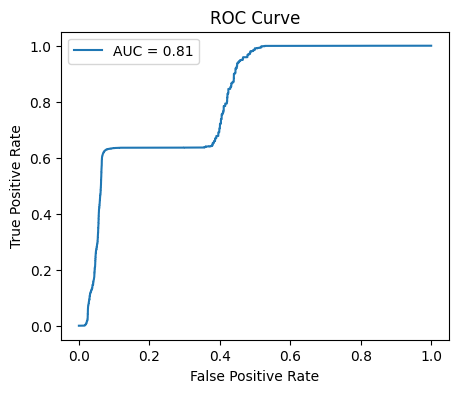

In [50]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# get anomaly scores
scores = model.decision_function(X_scaled)

fpr, tpr, _ = roc_curve(y, -scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("roc_curve.png", dpi=300)
plt.show()